In [1]:
!pip install -q -U datasets

In [2]:
### 4. Load GSM8K dataset (official train + test split)
from datasets import load_dataset

raw_train = load_dataset("openai/gsm8k", "main", split="train")
raw_test  = load_dataset("openai/gsm8k", "main", split="test")

print("Train size:", len(raw_train))
print("Test size :", len(raw_test))
print(raw_train[0])


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Train size: 7473
Test size : 1319
{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?', 'answer': 'Natalia sold 48/2 = <<48/2=24>>24 clips in May.\nNatalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.\n#### 72'}


In [3]:
# Data Analysis
train_df = raw_train.to_pandas()
test_df = raw_test.to_pandas()

print(train_df.head())

                                            question  \
0  Natalia sold clips to 48 of her friends in Apr...   
1  Weng earns $12 an hour for babysitting. Yester...   
2  Betty is saving money for a new wallet which c...   
3  Julie is reading a 120-page book. Yesterday, s...   
4  James writes a 3-page letter to 2 different fr...   

                                              answer  
0  Natalia sold 48/2 = <<48/2=24>>24 clips in May...  
1  Weng earns 12/60 = $<<12/60=0.2>>0.2 per minut...  
2  In the beginning, Betty has only 100 / 2 = $<<...  
3  Maila read 12 x 2 = <<12*2=24>>24 pages today....  
4  He writes each friend 3*2=<<3*2=6>>6 pages a w...  


In [4]:
# Dataset Shape
print("Training Samples :", train_df.shape)
print("Testing Samples :", test_df.shape)

Training Samples : (7473, 2)
Testing Samples : (1319, 2)


In [5]:
# Dataset Information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7473 entries, 0 to 7472
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  7473 non-null   object
 1   answer    7473 non-null   object
dtypes: object(2)
memory usage: 116.9+ KB


In [6]:
# Missing Value Analysis
train_df.isnull().sum()

question    0
answer      0
dtype: int64

In [7]:
# Duplicate Records
print(train_df.duplicated().sum())

0


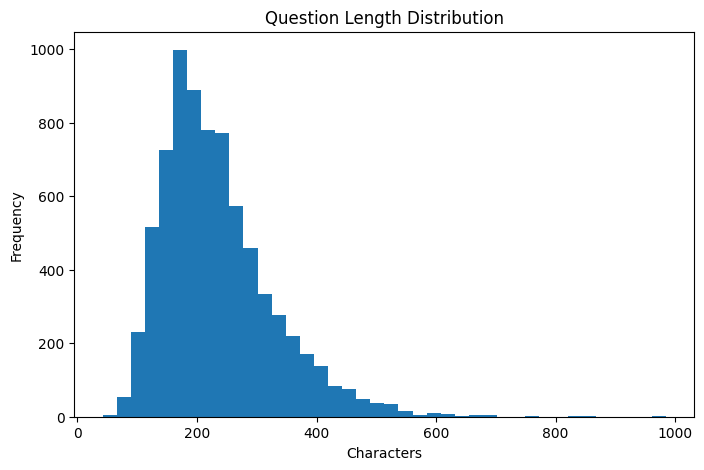

In [8]:
# Question Length Distribution
import matplotlib.pyplot as plt

train_df["question_length"] = train_df["question"].apply(len)

train_df["question_length"].describe()

plt.figure(figsize=(8,5))
plt.hist(train_df["question_length"], bins=40)
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Question Length Distribution")
plt.show()

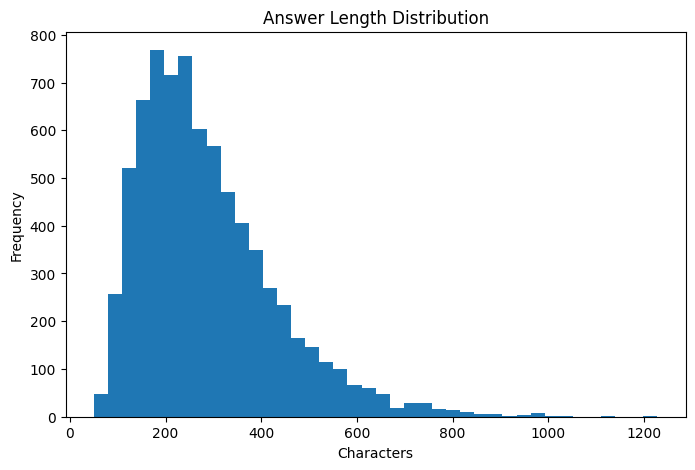

In [9]:
# Answer Length Distribution
import matplotlib.pyplot as plt

train_df["answer_length"] = train_df["answer"].apply(len)

plt.figure(figsize=(8,5))
plt.hist(train_df["answer_length"], bins=40)
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Answer Length Distribution")
plt.show()

In [10]:
# Word Count Analysis
train_df["question_words"] = train_df["question"].apply(lambda x: len(x.split()))
train_df["answer_words"] = train_df["answer"].apply(lambda x: len(x.split()))
print(train_df[["question_words","answer_words"]].describe())

       question_words  answer_words
count     7473.000000   7473.000000
mean        45.092600     51.711762
std         17.482279     26.731678
min          9.000000      4.000000
25%         33.000000     32.000000
50%         42.000000     47.000000
75%         54.000000     66.000000
max        183.000000    216.000000


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

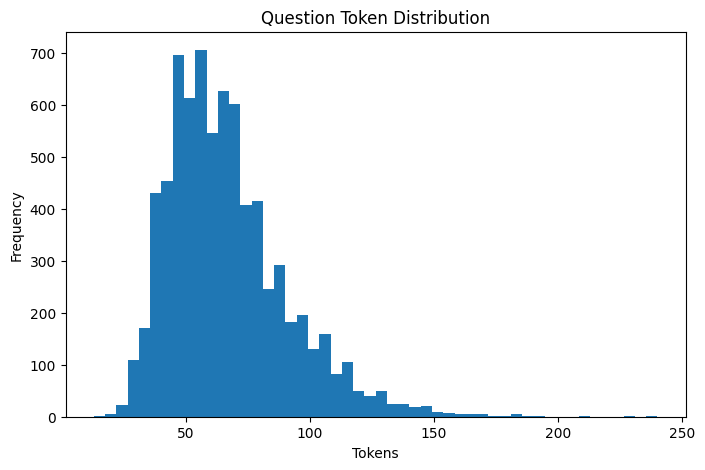

In [13]:
# Token Count Analysis
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")
train_df["tokens"] = train_df["question"].apply(
    lambda x: len(tokenizer(x)["input_ids"])
)

train_df["tokens"].describe()

plt.figure(figsize=(8,5))
plt.hist(train_df["tokens"], bins=50)
plt.title("Question Token Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.show()

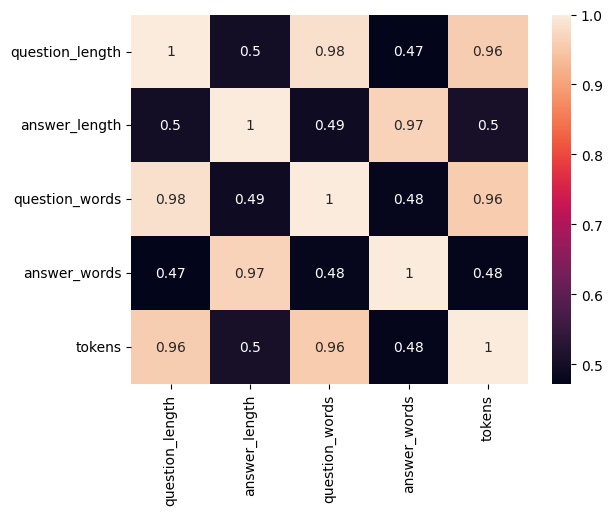

In [14]:
# Correlation Analysis

import seaborn as sns

sns.heatmap(
    train_df[
        ["question_length",
         "answer_length",
         "question_words",
         "answer_words",
         "tokens"]
    ].corr(),
    annot=True
)
plt.show()


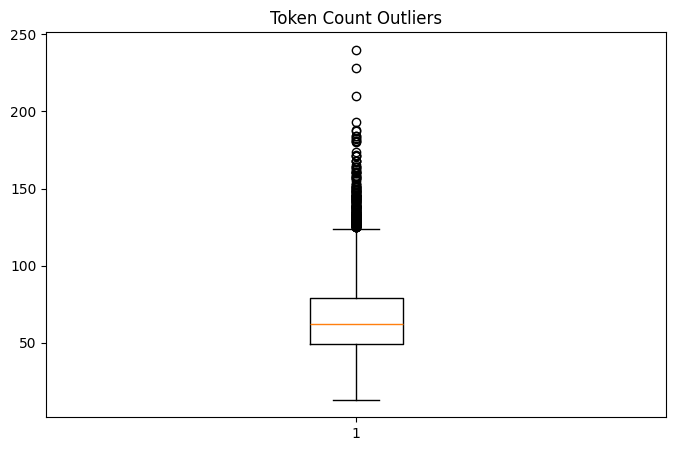

In [15]:
# Outliers
plt.figure(figsize=(8,5))
plt.boxplot(train_df["tokens"])
plt.title("Token Count Outliers")
plt.show()